In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/airline-ddelays-cause/Airline_Delay_Cause.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
file_path = '/kaggle/input/airline-ddelays-cause/Airline_Delay_Cause.csv'
data = pd.read_csv(file_path)

In [6]:
 data.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",72.0,5.0,2.46,1.00,...,0.0,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0
1,2023,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,7.0,4.25,0.00,...,0.0,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0
2,2023,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",95.0,10.0,5.94,0.00,...,0.0,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0
3,2023,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",23.0,2.0,0.56,0.00,...,0.0,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0
4,2023,12,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",2111.0,256.0,76.88,8.75,...,0.0,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0


In [7]:
 data.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,179338.000000,179338.000000,178997.000000,178747.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000
mean,2019.480082,6.485725,327.816969,58.709086,18.572643,2.035742,17.094929,0.145307,20.778477,6.830103,0.779572,3863.310676,1325.546199,209.113426,819.949284,6.839941,1501.854875
std,2.410204,3.463516,931.001446,164.378035,47.389651,6.894812,56.279604,0.702149,64.912766,41.446756,3.490499,11902.153241,4067.786987,791.817638,3178.603458,40.440497,4878.178427
min,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018.000000,3.000000,41.000000,6.000000,1.960000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,288.000000,91.000000,0.000000,28.000000,0.000000,54.000000
50%,2020.000000,6.000000,89.000000,15.000000,5.400000,0.220000,3.300000,0.000000,4.290000,1.000000,0.000000,900.000000,321.000000,12.000000,124.000000,0.000000,286.000000
75%,2022.000000,9.000000,218.000000,40.000000,14.700000,1.620000,9.860000,0.000000,13.010000,3.000000,1.000000,2547.000000,986.000000,131.000000,401.000000,0.000000,964.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,160.000000,438783.000000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


In [8]:
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

arr_flights            341
arr_del15              591
carrier_ct             341
weather_ct             341
nas_ct                 341
security_ct            341
late_aircraft_ct       341
arr_cancelled          341
arr_diverted           341
arr_delay              341
carrier_delay          341
weather_delay          341
nas_delay              341
security_delay         341
late_aircraft_delay    341
dtype: int64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


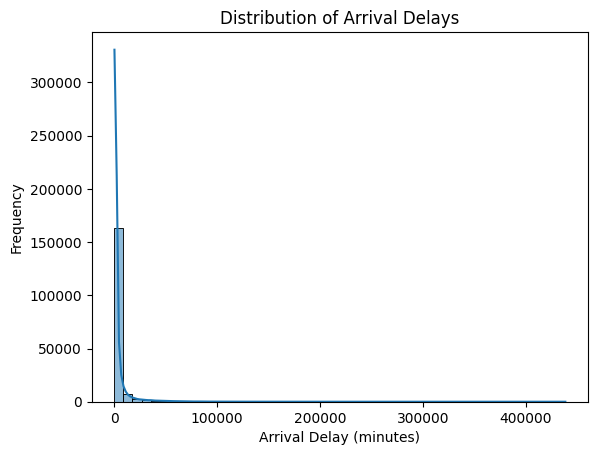

In [9]:
# Distribution of arrival delays (arr_delay)
sns.histplot(data['arr_delay'], bins=50, kde=True)
plt.title('Distribution of Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.show()
plt.savefig('arrival_delay_distribution.png')
plt.close()

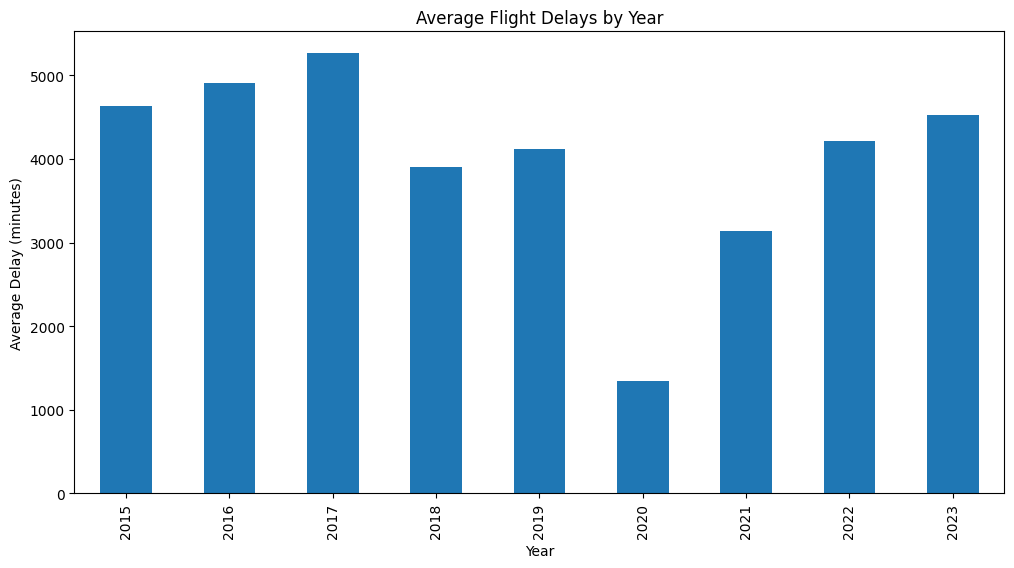

In [10]:
plt.figure(figsize=(12,6))
data.groupby('year')['arr_delay'].mean().plot(kind='bar')
plt.title('Average Flight Delays by Year')
plt.xlabel('Year')
plt.ylabel('Average Delay (minutes)')
plt.show()

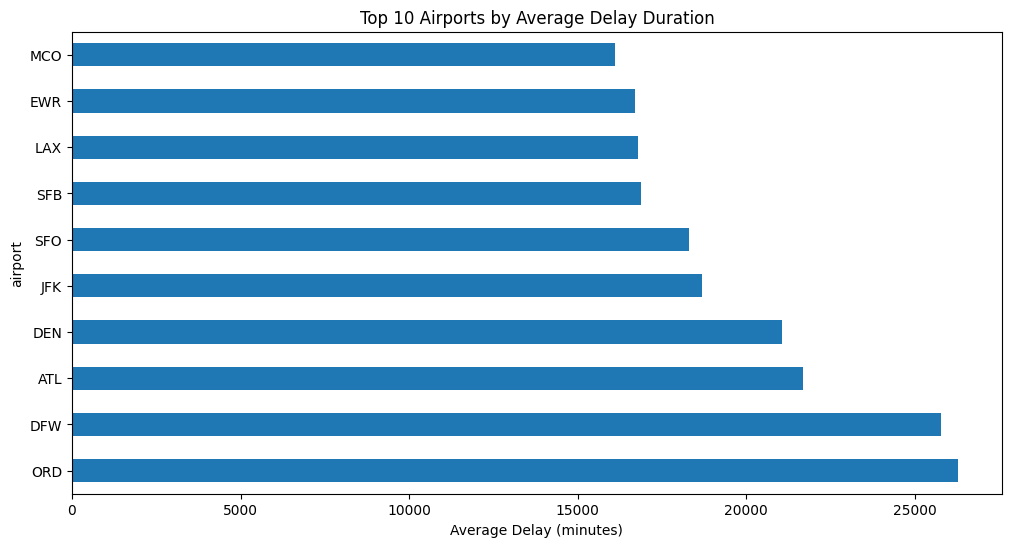

In [11]:
airport_delays = data.groupby('airport')['arr_delay'].mean().nlargest(10)
plt.figure(figsize=(12,6))
airport_delays.plot(kind='barh')
plt.title('Top 10 Airports by Average Delay Duration')
plt.xlabel('Average Delay (minutes)')
plt.show()

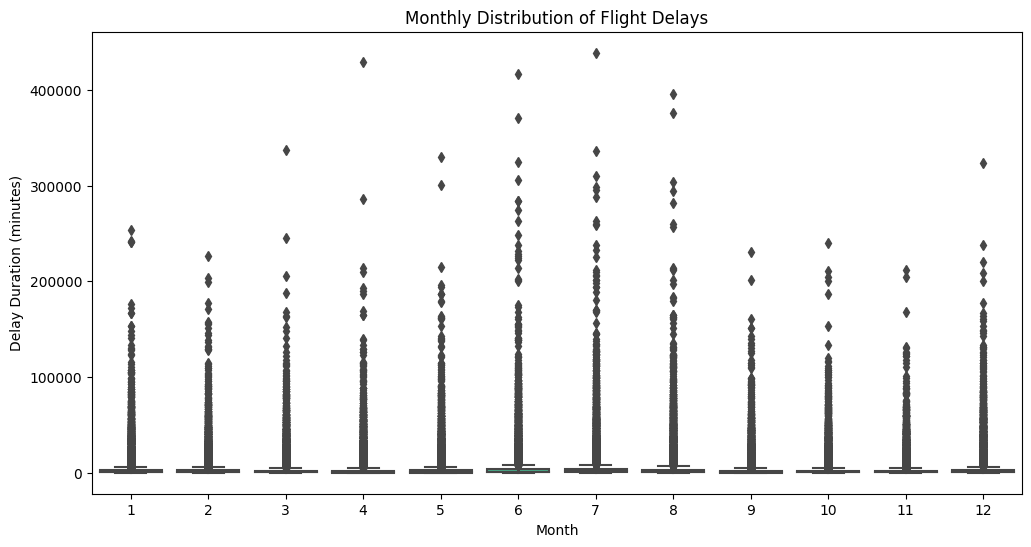

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(x='month', y='arr_delay', data=data)
plt.title('Monthly Distribution of Flight Delays')
plt.xlabel('Month')
plt.ylabel('Delay Duration (minutes)')
plt.show()

In [ ]:
yearly_cancellations = data.groupby(['year', 'carrier_name'])['arr_cancelled'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_cancellations, x='year', y='arr_cancelled', hue='carrier_name')
plt.title('Yearly Total Cancellations by Carrier')
plt.xlabel('Year')
plt.ylabel('Total Cancellations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

In [ ]:
# Count of delayed flights (arr_del15)
delayed_flights_count = data['arr_del15'].sum()

# Delay causes summary
delay_causes = data[['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']].sum()

In [ ]:
# Monthly delay pattern
monthly_delays = data.groupby('month')['arr_delay'].mean()

# Plot monthly average delay
plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_delays.index, y=monthly_delays.values)
plt.title('Average Arrival Delay by Month')
plt.xlabel('Month')
plt.ylabel('Average Arrival Delay (minutes)')
plt.show()
plt.savefig('monthly_average_delay.png')
plt.close()


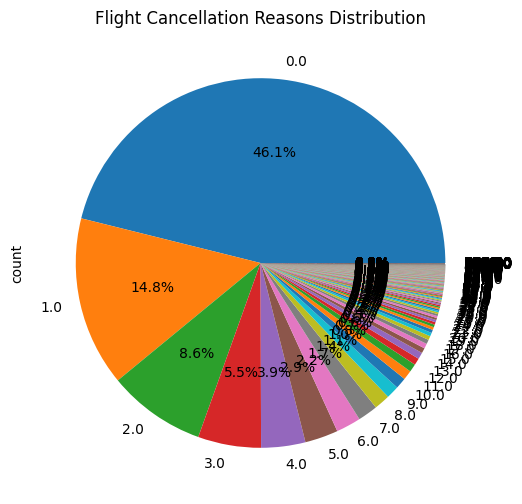

In [16]:
cancellation_causes = data['arr_cancelled'].value_counts()
plt.figure(figsize=(6,6))
cancellation_causes.plot.pie(autopct='%1.1f%%')
plt.title('Flight Cancellation Reasons Distribution')
plt.show()

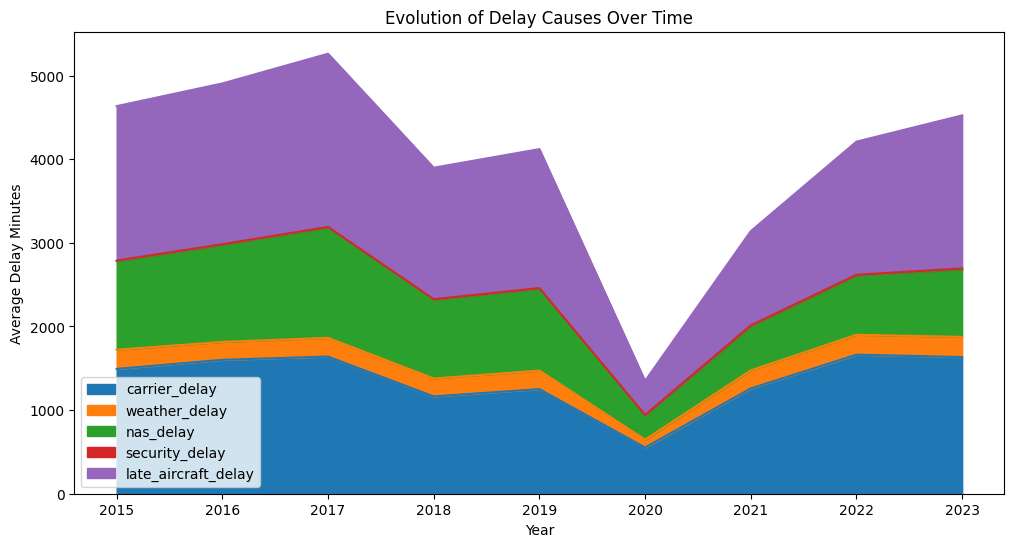

In [17]:
delay_causes = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
delay_types_over_time = data.groupby('year')[delay_causes].mean()
delay_types_over_time.plot(kind='area', stacked=True, figsize=(12,6))
plt.title('Evolution of Delay Causes Over Time')
plt.xlabel('Year')
plt.ylabel('Average Delay Minutes')
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [19]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

# For count variables, use PMM to ensure non-negative integers
mice_imputer_counts = IterativeImputer(
    random_state=42,
    max_iter=10,
    sample_posterior=True  # Enables PMM-like behavior
)
# Step 1: Log-transform delay variables (add 1 to handle zeros)
delay_cols = ['arr_delay', 'carrier_delay', 'weather_delay', 
              'nas_delay', 'security_delay', 'late_aircraft_delay']

# Transform
for col in delay_cols:
    data[f'{col}_log'] = np.log1p(data[col])  # log(1+x) to handle zeros

# Step 2: Impute transformed variables
mice_imputer_delays = IterativeImputer(
    random_state=42,
    max_iter=10
)

# Step 3: Back-transform after imputation
for col in delay_cols:
    data[col] = np.expm1(data[f'{col}_log'])  # exp(x)-1 to back-transform

In [20]:
# Group by airport and carrier for context-aware imputation
def group_imputation(data, group_cols=['airport', 'carrier']):
    imputed_data = data.copy()
    
    for group_name, group_data in data.groupby(group_cols):
        if len(group_data) > 5:  # Minimum group size
            # Apply MICE within each group
            group_imputed = mice_imputer_counts.fit_transform(
                group_data[count_columns]
            )
            imputed_data.loc[group_data.index, count_columns] = group_imputed
    
    return imputed_data


In [21]:
def apply_constraints(data):
    # Ensure delays are non-negative
    delay_cols = ['arr_delay', 'carrier_delay', 'weather_delay',
                    'nas_delay', 'security_delay', 'late_aircraft_delay']
    data[delay_cols] = data[delay_cols].clip(lower=0)
    
    # Ensure counts are non-negative integers
    count_cols = ['arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct',
                    'nas_ct', 'security_ct', 'late_aircraft_ct']
    data[count_cols] = data[count_cols].round().clip(lower=0).astype(int)
    
    # Logical constraint: delayed flights ≤ total flights
    data['arr_del15'] = np.minimum(data['arr_del15'], data['arr_flights'])

    return data


In [22]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np

def comprehensive_imputation(data):
    # Define variable groups
    count_vars = ['arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct',
                   'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled',
                   'arr_diverted']

    delay_vars = ['arr_delay', 'carrier_delay', 'weather_delay',
                   'nas_delay', 'security_delay', 'late_aircraft_delay']

    # 1. Impute count variables with PMM
    mice_counts = IterativeImputer(random_state=42, max_iter=10,
                                   sample_posterior=True)
    data[count_vars] = mice_counts.fit_transform(data[count_vars])

    # 2. Log-transform delay variables
    for col in delay_vars:
        data[f'{col}_log'] = np.log1p(data[col])

    # 3. Impute transformed delays
    mice_delays = IterativeImputer(random_state=42, max_iter=10)
    log_cols = [f'{col}_log' for col in delay_vars]
    data[log_cols] = mice_delays.fit_transform(data[log_cols])

    # 4. Back-transform delays
    for col in delay_vars:
        data[col] = np.expm1(data[f'{col}_log'])

        data.drop(f'{col}_log', axis=1, inplace=True)

    # 5. Apply constraints
    data = apply_constraints(data)

    return data

# Apply imputation
data_imputed = comprehensive_imputation(data)


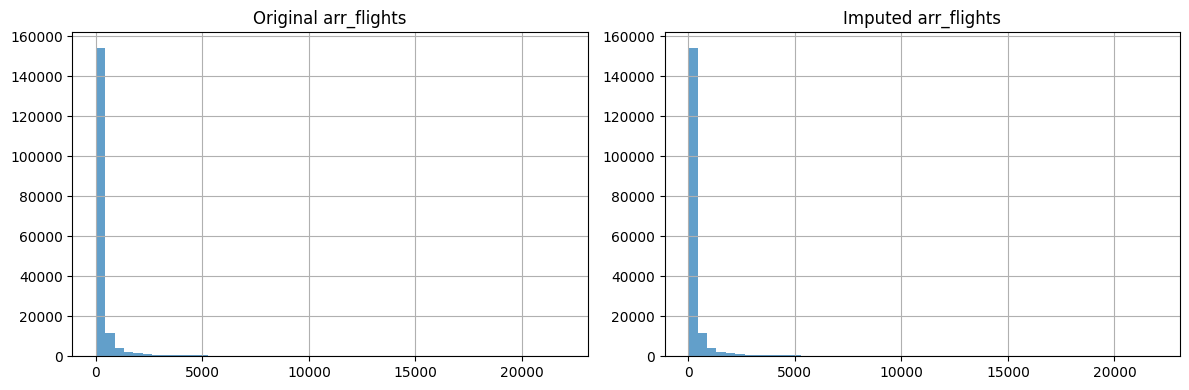

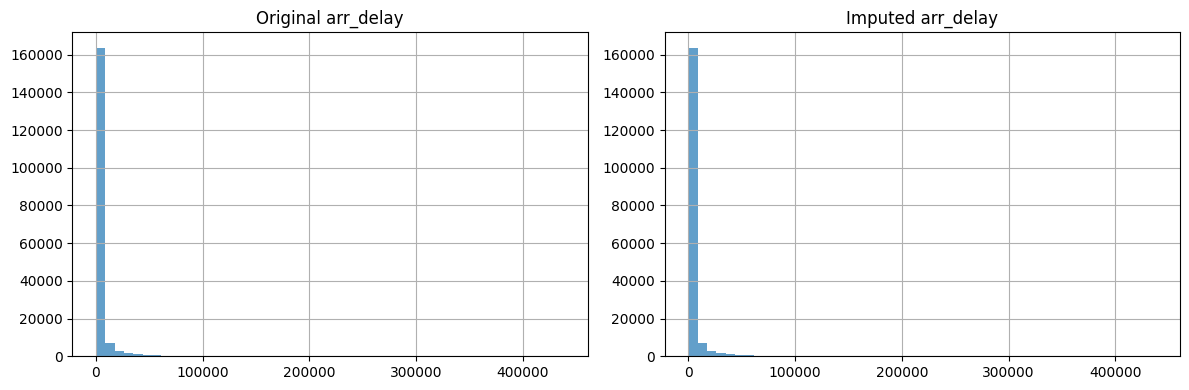

In [23]:
# Check imputation patterns
import matplotlib.pyplot as plt

def assess_imputation_quality(original_data, imputed_data):
    # Compare distributions
    for col in ['arr_flights', 'arr_delay']:
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        original_data[col].hist(alpha=0.7, label='Original', bins=50)
        plt.title(f'Original {col}')
        
        plt.subplot(1, 2, 2)
        imputed_data[col].hist(alpha=0.7, label='Imputed', bins=50)
        plt.title(f'Imputed {col}')
        
        plt.tight_layout()
        plt.show()

assess_imputation_quality(data, data_imputed)


In [24]:
missing_values = data_imputed.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [25]:
# Prepare data for classification (delayed or not)
data['delayed'] = (data['arr_del15'] > 0).astype(int)

# Encode categorical variables
le_carrier = LabelEncoder()
data['carrier_encoded'] = le_carrier.fit_transform(data['carrier'])
le_airport = LabelEncoder()
data['airport_encoded'] = le_airport.fit_transform(data['airport'])

# Features and target for classification
features = ['year', 'month', 'carrier_encoded', 'airport_encoded', 'arr_flights' ]

X = data[features]
y_class = data['delayed']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    r2_score
)

# Split data for classifier
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]



# Prepare data for regression (delay duration)
y_reg = data['arr_delay']

# Split data for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Train regressor
reg = RandomForestRegressor(
    n_estimators=500,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    bootstrap=True,
    criterion='squared_error',
    random_state=42
)
reg.fit(X_train_reg, y_train_reg)

# Evaluate regressor (R^2 score)
y_pred_reg = reg.predict(X_test_reg)

Operational Adjustability Index (OAI): 38646156.37


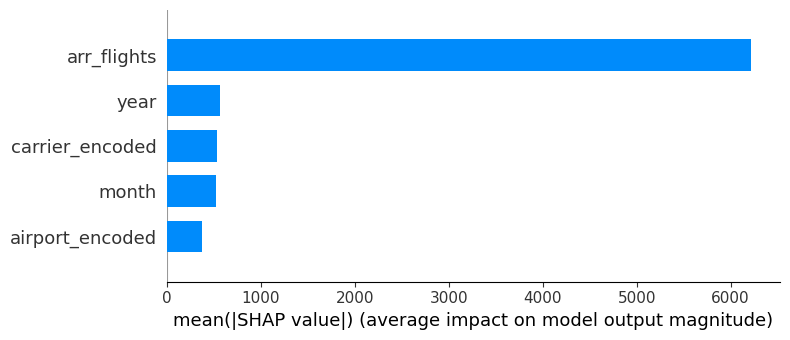

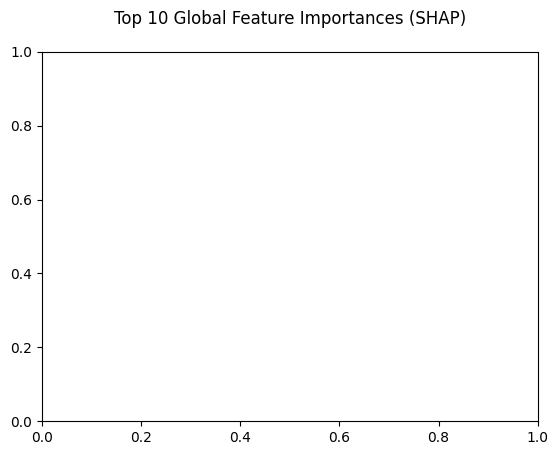

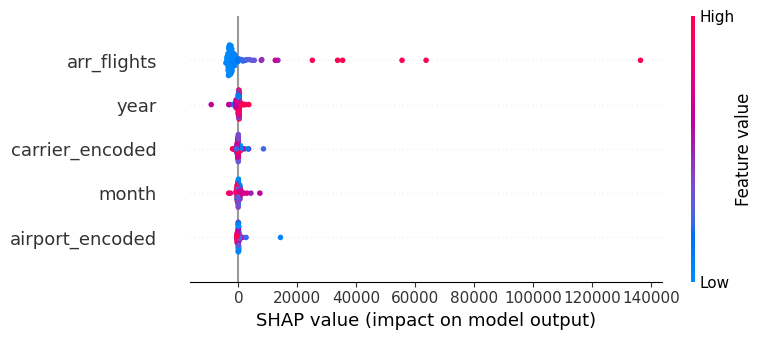

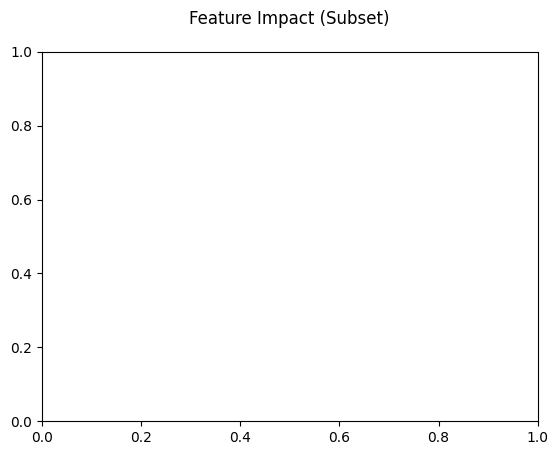

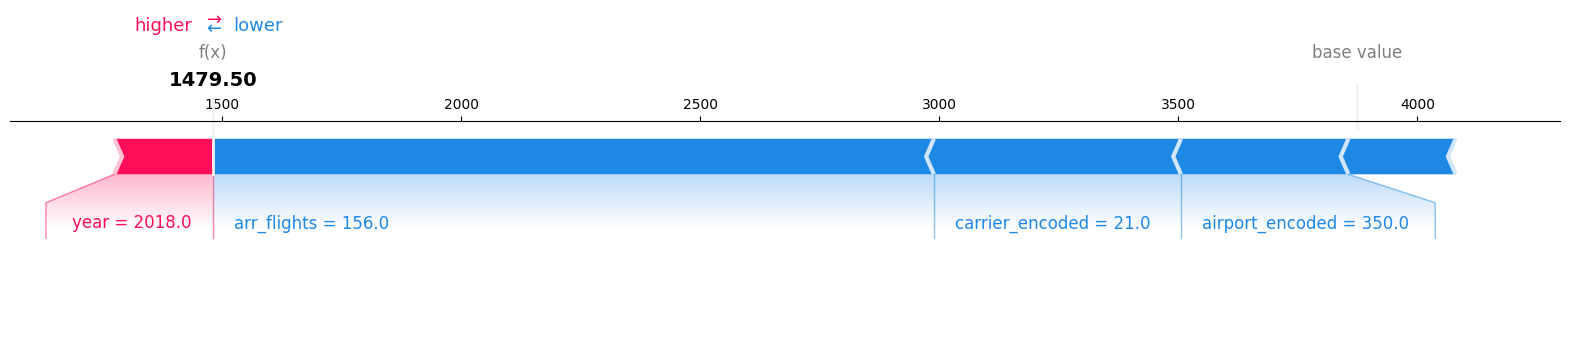

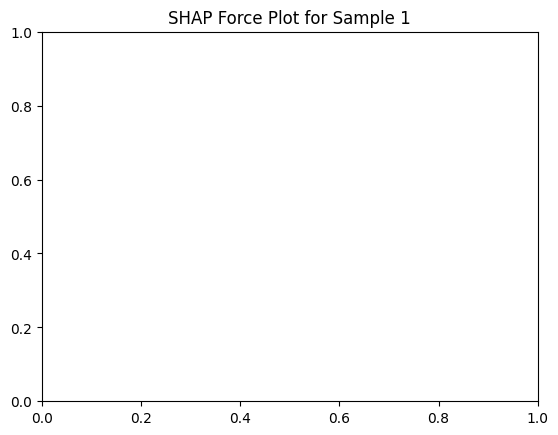

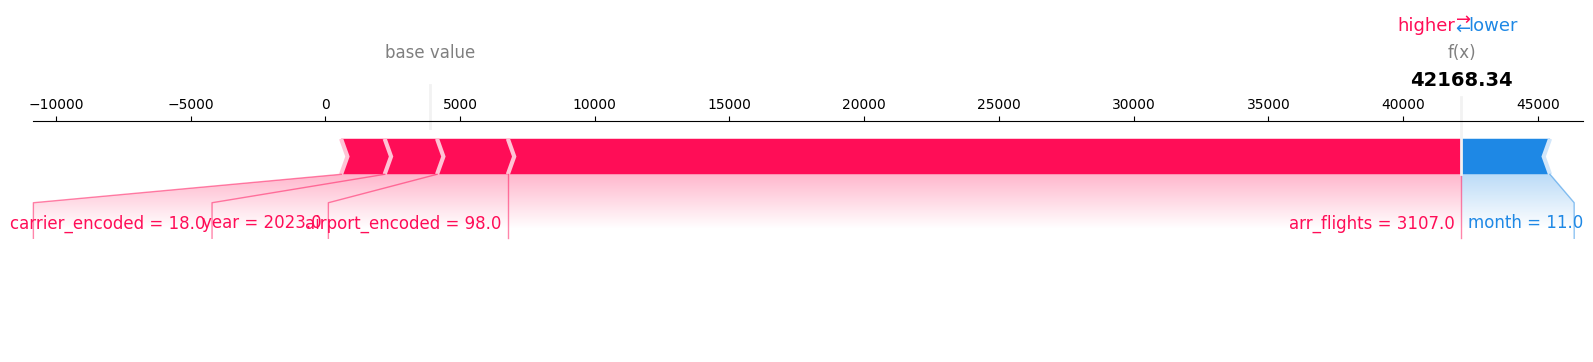

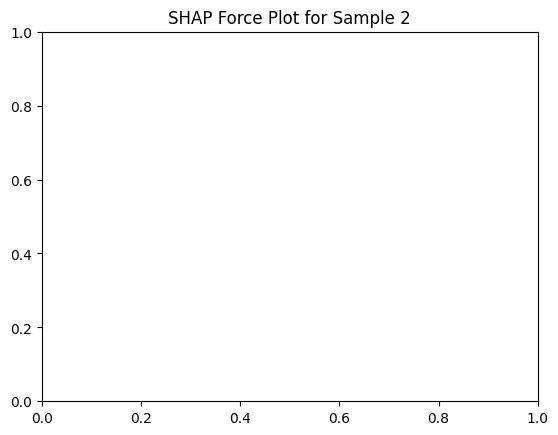

In [27]:
import shap

def operational_adjustability_index(y_true, y_pred, X_controllable, controllable_weights):
    # controllable_weights: dict of weights for controllable delay causes (e.g., carrier_ct, late_aircraft_ct)
    # X_controllable: DataFrame with controllable delay counts
    controllable_delay = sum(X_controllable[col] * controllable_weights[col] for col in controllable_weights)
    controllable_error = np.sum((y_pred - y_true)**2 * controllable_delay) / np.sum(controllable_delay)
    return controllable_error

# Example weights for controllable delays (carrier_ct, late_aircraft_ct)
controllable_weights = {'carrier_ct': 2.0, 'late_aircraft_ct': 1.5}
X_controllable = data_imputed[['carrier_ct', 'late_aircraft_ct']]

# Calculate OAI
#y_pred = reg.predict(X_test)
oai = operational_adjustability_index(y_test_reg, y_pred_reg, X_controllable, controllable_weights)
print(f"Operational Adjustability Index (OAI): {oai:.2f}")

# Reduce number of samples for faster explanation
sample_indices = np.random.permutation(len(X_test_reg))[:100]  # or even 50
X_test_subsample = X_test_reg.iloc[sample_indices]

# Calculate SHAP values for this small sample
explainer = shap.TreeExplainer(reg)
shap_values = explainer.shap_values(X_test_subsample)

# Summary plot with max_display to cut down number of features
shap.summary_plot(shap_values, X_test_subsample, plot_type='bar', max_display=10)
plt.title("Top 10 Global Feature Importances (SHAP)", pad=20)
plt.show()

# Summary plot with less points
shap.summary_plot(shap_values, X_test_subsample, max_display=10)
plt.title("Feature Impact (Subset)", pad=20)
plt.show()

# Force plot for just a few samples
for i in range(min(2, len(X_test_subsample))):
    shap.force_plot(explainer.expected_value, 
                     shap_values[i], 
                     X_test_subsample.iloc[i,:],
                     matplotlib=True)
    plt.title(f"SHAP Force Plot for Sample {i+1}")
    plt.show()



In [28]:
# Evaluation metrics for classifier
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Classifier Accuracy: {acc*100:.2f}%')
print(f'Classifier Precision: {prec*100:.2f}%')
print(f'Classifier Recall: {rec*100:.2f}%')
print(f'Classifier F1 Score: {f1*100:.2f}%')

r2 = r2_score(y_test_reg, y_pred_reg)
print(f'Regression R^2 Score: {r2*100:.2f}%')

Classifier Accuracy: 96.31%
Classifier Precision: 97.50%
Classifier Recall: 98.65%
Classifier F1 Score: 98.07%
Regression R^2 Score: 90.90%


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test_reg, y_pred_reg)
print("Mean Absolute Error (MAE):", mae)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test_reg, y_pred_reg)
print("Mean Squared Error (MSE):", mse)

Mean Absolute Error (MAE): 1075.6582067031545
Mean Squared Error (MSE): 11524498.701007733


In [30]:
from sklearn.metrics import confusion_matrix

# First make predictions with your trained classifier
y_pred = clf.predict(X_test)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[  845   864]
 [  460 33699]]


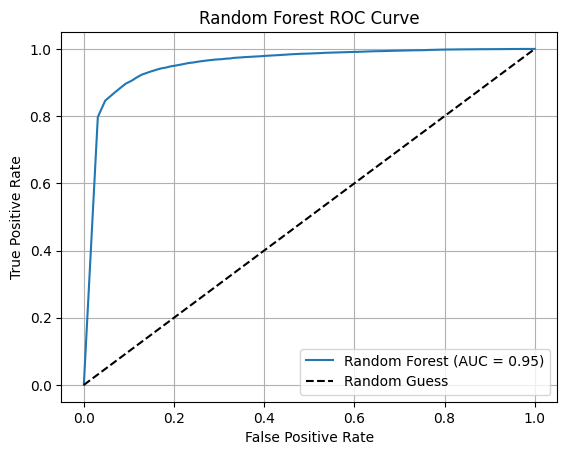

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities for positive class
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()